# Preparing dataset for finetuning

## What this notebook does
- Loads the items dataset from HuggingFace Hub (lite or full)
- Counts tokens for each item's summary using a tokenizer
- Applies a token cutoff and builds prompt/completion pairs
- Pushes the final prompt dataset back to HuggingFace Hub

## Step 1: Install dependencies

In [1]:
# Run this cell first on Google Colab
!pip install -q datasets transformers pydantic huggingface_hub tqdm matplotlib

## Step 2: Imports

In [2]:
import os
import re
from typing import Optional
from pydantic import BaseModel
from datasets import Dataset, DatasetDict, load_dataset
from huggingface_hub import login
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

## Step 3: Item class (utility code inlined from `pricer/items.py`)

This replaces the `from pricer.items import Item` import that only works locally.

In [3]:
PREFIX = "Price is $"
QUESTION = "What does this cost to the nearest dollar?"


class Item(BaseModel):
    """
    An Item is a data-point of a Product with a Price.
    Inlined from pricer/items.py for use in Google Colab.
    """

    title: str
    category: str
    price: float
    full: Optional[str] = None
    weight: Optional[float] = None
    summary: Optional[str] = None
    prompt: Optional[str] = None
    completion: Optional[str] = None
    id: Optional[int] = None

    def make_prompt(self, text: str):
        """Create a simple prompt with rounded price as completion."""
        self.prompt = f"{QUESTION}\n\n{text}\n\n{PREFIX}{round(self.price)}.00"

    def test_prompt(self) -> str:
        """Return the prompt without the answer (for inference)."""
        return self.prompt.split(PREFIX)[0] + PREFIX

    def __repr__(self) -> str:
        return f"<{self.title} = ${self.price}>"

    def count_tokens(self, tokenizer) -> int:
        """Count tokens in the item summary."""
        return len(tokenizer.encode(self.summary, add_special_tokens=False))

    def make_prompts(self, tokenizer, max_tokens: int, do_round: bool):
        """
        Build prompt and completion strings.
        Truncates summary to max_tokens if needed.
        do_round=True  -> completion is rounded price (for train/val)
        do_round=False -> completion is raw price  (for test)
        """
        tokens = tokenizer.encode(self.summary, add_special_tokens=False)
        if len(tokens) > max_tokens:
            summary = tokenizer.decode(tokens[:max_tokens]).rstrip()
        else:
            summary = self.summary
        self.prompt = f"{QUESTION}\n\n{summary}\n\n{PREFIX}"
        self.completion = f"{round(self.price)}.00" if do_round else str(self.price)

    def count_prompt_tokens(self, tokenizer) -> int:
        """Count tokens in the full prompt+completion string."""
        full = self.prompt + self.completion
        tokens = tokenizer.encode(full, add_special_tokens=False)
        return len(tokens)

    def to_datapoint(self) -> dict:
        """Return minimal dict for SFT training."""
        return {"prompt": self.prompt, "completion": self.completion}

    @staticmethod
    def push_to_hub(dataset_name: str, train: list, val: list, test: list):
        """Push Item lists to HuggingFace Hub."""
        DatasetDict(
            {
                "train": Dataset.from_list([item.model_dump() for item in train]),
                "validation": Dataset.from_list([item.model_dump() for item in val]),
                "test": Dataset.from_list([item.model_dump() for item in test]),
            }
        ).push_to_hub(dataset_name)

    @classmethod
    def from_hub(cls, dataset_name: str) -> tuple:
        """Load items from HuggingFace Hub."""
        ds = load_dataset(dataset_name)
        return (
            [cls.model_validate(row) for row in ds["train"]],
            [cls.model_validate(row) for row in ds["validation"]],
            [cls.model_validate(row) for row in ds["test"]],
        )

    @staticmethod
    def push_prompts_to_hub(dataset_name: str, train: list, val: list, test: list):
        """Push prompt-completion pairs to HuggingFace Hub for SFT training."""
        DatasetDict(
            {
                "train": Dataset.from_list([item.to_datapoint() for item in train]),
                "val": Dataset.from_list([item.to_datapoint() for item in val]),
                "test": Dataset.from_list([item.to_datapoint() for item in test]),
            }
        ).push_to_hub(dataset_name)


print("Item class defined successfully.")

Item class defined successfully.


In [4]:
# ============================================================
#  USER SETTINGS
# ============================================================

BASE_MODEL = "meta-llama/Llama-3.2-3B"

# Your HuggingFace username (for pushing the output dataset)
YOUR_HF_USERNAME = "Aditya2302"  # <-- change this!

# Source dataset owner (keep as ed-donner unless you have your own copy)
SOURCE_USERNAME = "Aditya2302"

# ============================================================
print(f"BASE_MODEL   : {BASE_MODEL}")
print(f"Dataset owner: {SOURCE_USERNAME}")
print(f"Your username: {YOUR_HF_USERNAME}")

BASE_MODEL   : meta-llama/Llama-3.2-3B
Dataset owner: Aditya2302
Your username: Aditya2302


## Step 5: HuggingFace Login

You need a HuggingFace token with **read** (to download the dataset and model) and **write** (to push your output dataset) permissions.

Get yours at: https://huggingface.co/settings/tokens

On Colab, use the **Secrets** panel (key icon in the left sidebar) and add a secret named `HF_TOKEN`.

In [5]:
from huggingface_hub import login
import getpass

try:
    # Try Colab secrets first
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
    print("Loaded HF_TOKEN from Colab secrets.")
except Exception:
    # Fallback: ask for token interactively
    hf_token = getpass.getpass("Enter your HuggingFace token: ")

login(hf_token, add_to_git_credential=True)
print("Logged in to HuggingFace.")

Loaded HF_TOKEN from Colab secrets.
Logged in to HuggingFace.


## Step 6: Load dataset from HuggingFace Hub

In [6]:
dataset_name = f"{SOURCE_USERNAME}/items_lite"
print(f"Loading dataset: {dataset_name} ...")

train, val, test = Item.from_hub(dataset_name)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")
print(f"Total: {len(items):,} items")

Loading dataset: Aditya2302/items_lite ...


README.md:   0%|          | 0.00/735 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 6.16MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  308kB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loaded 20,000 training items, 1,000 validation items, 1,000 test items
Total: 22,000 items


## Step 7: Load tokenizer

In [7]:
print(f"Loading tokenizer for: {BASE_MODEL} ...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
print(f"Tokenizer loaded: {tokenizer.__class__.__name__}")

Loading tokenizer for: meta-llama/Llama-3.2-3B ...


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Tokenizer loaded: TokenizersBackend


## Step 8: Count tokens per item summary

In [8]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items, desc="Counting tokens")]

Counting tokens:   0%|          | 0/22000 [00:00<?, ?it/s]

## Step 9: Visualise token distribution

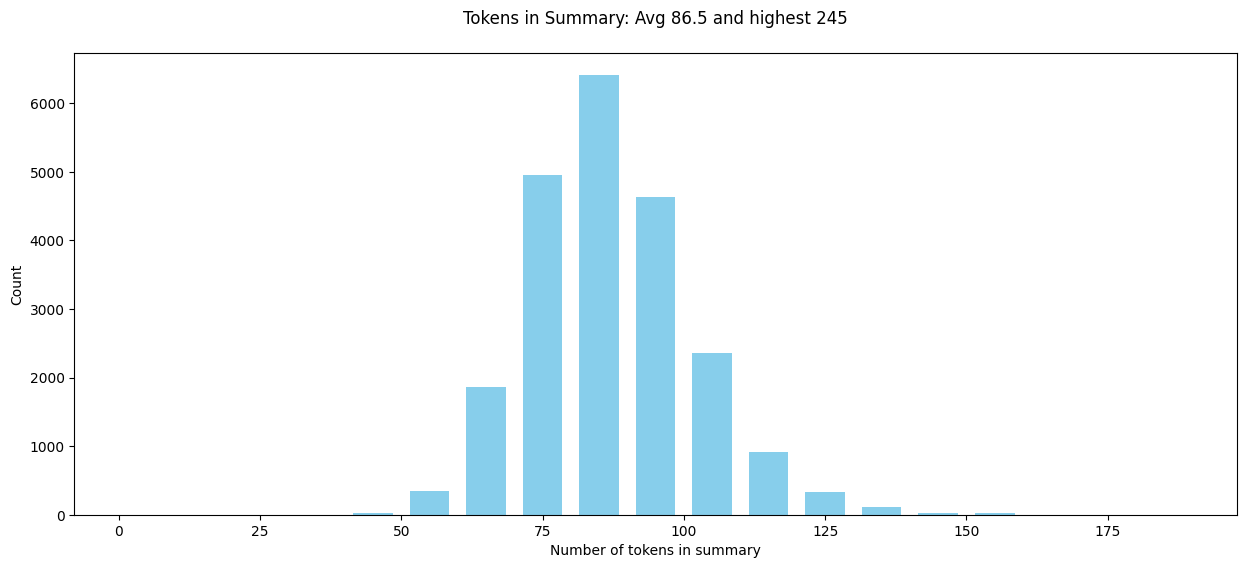

In [9]:
avg_tokens = sum(token_counts) / len(token_counts)
max_tokens_seen = max(token_counts)

plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {avg_tokens:,.1f} and highest {max_tokens_seen:,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

## Step 10: Choose a token cutoff

In [10]:
CUTOFF = 110

cut = len([count for count in token_counts if count > CUTOFF])
print(f"With CUTOFF={CUTOFF}, we will truncate {cut:,} items which is {cut/len(items):.1%} of total")

With CUTOFF=110, we will truncate 1,255 items which is 5.7% of total


## Step 11: Inspect a sample item

In [11]:
print("Sample training item summary:")
print("-" * 60)
print(train[0].summary)

Sample training item summary:
------------------------------------------------------------
Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.


## Step 12: Build prompt / completion pairs

In [12]:
# Train + validation: rounded price as completion
for item in tqdm(train + val, desc="Building train/val prompts"):
    item.make_prompts(tokenizer, CUTOFF, True)

# Test: raw price as completion (for evaluation)
for item in tqdm(test, desc="Building test prompts"):
    item.make_prompts(tokenizer, CUTOFF, False)

Building train/val prompts:   0%|          | 0/21000 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Building test prompts:   0%|          | 0/1000 [00:00<?, ?it/s]

## Step 13: Inspect a sample prompt

In [13]:
print("PROMPT:")
print("-" * 60)
print(test[0].prompt)
print("\nCOMPLETION:")
print("-" * 60)
print(test[0].completion)

PROMPT:
------------------------------------------------------------
What does this cost to the nearest dollar?

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.

Price is $

COMPLETION:
------------------------------------------------------------
219.0


## Step 14: Count tokens in full prompt+completion

In [14]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items, desc="Counting prompt tokens")]

Counting prompt tokens:   0%|          | 0/22000 [00:00<?, ?it/s]

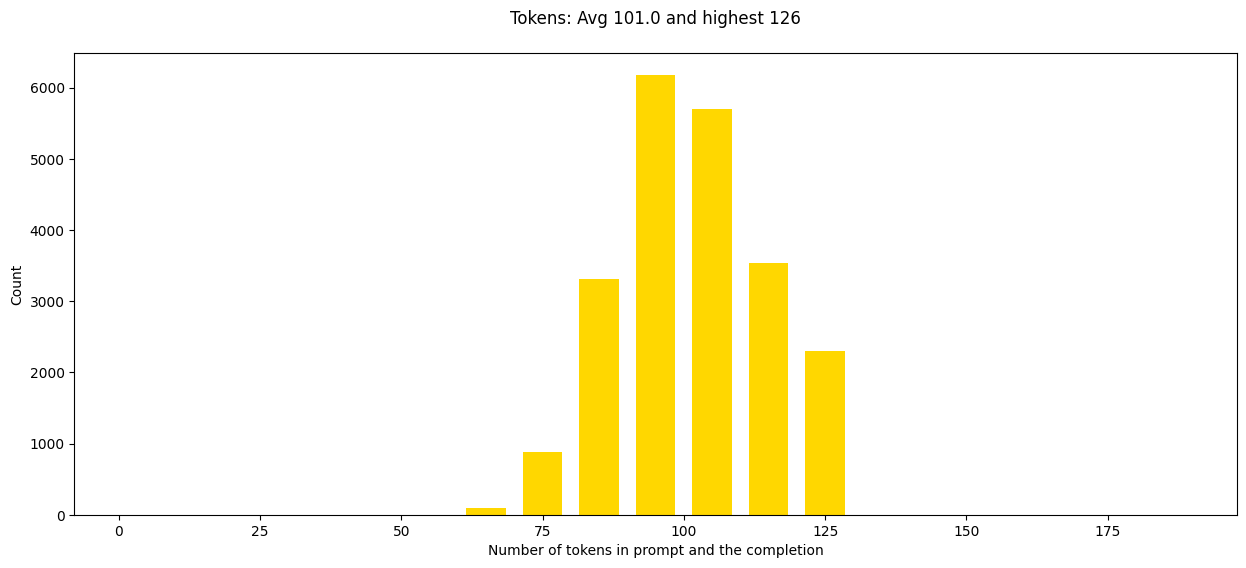

In [15]:
avg_prompt = sum(prompt_token_counts) / len(prompt_token_counts)
max_prompt = max(prompt_token_counts)

plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {avg_prompt:,.1f} and highest {max_prompt:,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 200, 10))
plt.show()

## Step 15: Push prompt dataset to HuggingFace Hub

Make sure `YOUR_HF_USERNAME` in Step 4 is set correctly before running this.

In [16]:
output_dataset = f"{YOUR_HF_USERNAME}/items_prompts_lite"

print(f"Pushing to: {output_dataset} ...")
Item.push_prompts_to_hub(output_dataset, train, val, test)
print(f"Dataset pushed to: https://huggingface.co/datasets/{output_dataset}")

Pushing to: Aditya2302/items_prompts_lite ...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/20 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  64%|######3   |  140kB /  221kB            

Dataset pushed to: https://huggingface.co/datasets/Aditya2302/items_prompts_lite


## Done!

The prompt dataset is now on HuggingFace and ready for fine-tuning.
